# 11. Functional Profiling II: Functional Differential Abundance Analysis

This notebook continues the functional profiling workflow from the first notebook. In that notebook, we completed the installation and setup of PICRUSt2, prepared the input data, and ran the PICRUSt2 pipeline. We also assessed the quality of the predictions using NSTI values, which confirmed that the detected ASVs were well represented in the reference genome database. The PICRUSt2 outputs were then converted into QIIME 2 artifacts for KEGG Orthologs (KOs), Enzyme Commission (EC) numbers, and MetaCyc pathway abundances. Following this, we performed a functional beta diversity analysis.

In this second notebook, we focus on functional differential abundance analysis. We will use ANCOM-BC to test for differences in predicted pathway abundances across all metadata variables. This analysis will allow us to identify functional features whose predicted abundances vary significantly with variables such as age, diet, delivery mode, geographic location, and treatment exposure.


### Notebook Structure
**0.** Setup 
<span style="color:gray">  
**1.** Install PICRUSt2  
**2.** Prepare the Inputs  
**3.** Run PICRUSt2  
**4.** Analyse the Results  
&nbsp;&nbsp;&nbsp;&nbsp;**4.1** Prediction quality control: NSTI values  
&nbsp;&nbsp;&nbsp;&nbsp;**4.2** Conversion of PICRUSt2 predictions into QIIME 2 artifacts  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; - KEGG Orthologs (KOs)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; - Enzyme Commission (EC) numbers  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; - MetaCyc pathway abundances  
&nbsp;&nbsp;&nbsp;&nbsp;**4.3** Functional beta diversity analysis 
</span>  
&nbsp;&nbsp;&nbsp;&nbsp;**4.4** Functional Differential Abundance Analysis


## 0. Setup

In [1]:
# Import all necessary packages
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from math import sqrt
import numpy as np
%matplotlib inline

In [2]:
# Set working directory
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
daa_data_dir = "../data/processed/differential_abundance"
function_preds_data_dir = "../data/processed/function_preds"
pathways_data_dir=f"{function_preds_data_dir}/pathways_results"
pathways_daa_data_dir=f"{function_preds_data_dir}/daa_data_dir"
# Create the new differential abundance analysis folder (in data/processed/function_preds/pathways_results)

In [4]:
%%bash -s "$daa_data_dir"
mkdir -p "$1"

### 4.4. Functional Differential Abundance Analysis
Microbiome differential abundance analysis is challenging due to sparsity and high sample-to-sample variability. No single statistical method performs optimally across all community structures, effect sizes, or preprocessing choices. In our previous analysis at the collapsed taxa level, we applied three complementary methods (ANCOM-BC, MaAsLin2, and DESeq2) to identify a robust consensus set of features consistently detected across methods, increasing confidence in the biological relevance of the results.

For the functional differential abundance analysis, we only use ANCOM-BC, since setting up and running MaAsLin2 or DESeq2 in the Jupyter notebook environment is quite time-consuming. Installing the required R dependencies on the JupyterHub server can take several hours and must be repeated after every server restart.

We will use ANCOM-BC to perform functional differential abundance analysis on predicted pathway abundances across all metadata variables. By focusing on pathways rather than individual KOs or ECs, we capture higher-level functional modules, reduce noise from sparsely predicted features, and facilitate biologically meaningful interpretation.

#### Data Exploration: look at feature table and data distribution
We begin by inspecting the predicted pathway abundances to assess sparsity (i.e. lots of zero values) and to get an overview of the data distribution.

In [5]:
# import and plot feature table to check for zero-values
data = q2.Artifact.load(f'{pathways_data_dir}/pathway_table.qza').view(pd.DataFrame)

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
data.head()

,12DICHLORETHDEG-PWY,14DICHLORBENZDEG-PWY,1CMET2-PWY,3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,4-HYDROXYMANDELATE-DEGRADATION-PWY,AEROBACTINSYN-PWY,ALLANTOINDEG-PWY,ANAEROFRUCAT-PWY,ANAGLYCOLYSIS-PWY,ARG+POLYAMINE-SYN,...,THISYNARA-PWY,THRESYN-PWY,TOLUENE-DEG-3-OH-PWY,TRNA-CHARGING-PWY,TRPSYN-PWY,TYRFUMCAT-PWY,UDPNAGSYN-PWY,URDEGR-PWY,URSIN-PWY,VALSYN-PWY
SRR8115637,0.0,0.0,27158.722347,766.330717,0.0,0.00,5321.495214,31106.445220,48399.642707,13754.019907,...,33703.279958,71096.332346,0.0,40567.816422,0.0,21.081899,51487.884657,5598.710617,1145.717523,68679.926117
SRR8115646,0.0,0.0,30299.379186,0.000000,0.0,0.00,151.961212,26618.584435,39435.433706,4810.932338,...,28451.407562,39916.527933,0.0,31189.018202,0.0,0.000000,27912.757622,145.291536,184.490870,37936.555772
SRR8115666,0.0,0.0,7234.594709,17.287042,0.0,10.12,184.292182,5712.645905,9216.946743,2428.209190,...,7374.392334,8667.468764,0.0,7376.541407,0.0,0.000000,3491.365776,195.220632,28.261047,8969.509329
SRR8115682,0.0,0.0,8624.583586,24.097152,0.0,0.00,77.108469,8716.568204,11760.128534,1034.625074,...,9071.180428,13938.253928,0.0,9672.469041,0.0,4.125000,10512.092428,73.668281,39.135819,14451.745269
SRR8115685,0.0,0.0,9866.071624,5.172865,0.0,3.38,0.000000,8965.816157,12497.361053,1786.161462,...,10184.099212,14637.379869,0.0,8969.524238,0.0,0.000000,10303.873084,2.524467,9.438458,15459.872563


We can see that the pathway table contains many zero values. Next, we check whether the data is normally distributed.

In [7]:
#violin plot to check if data is normally distributed
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

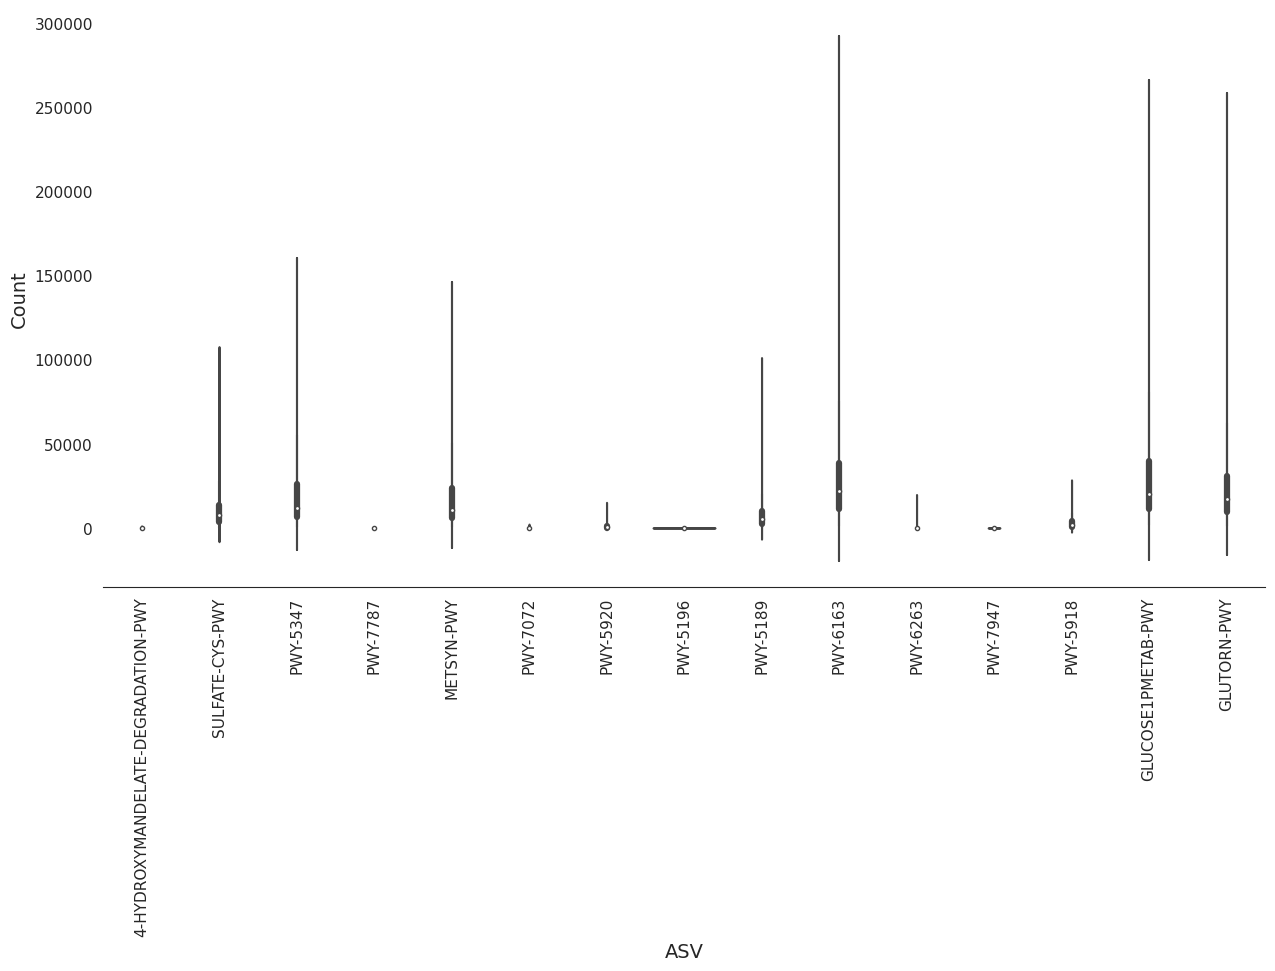

In [8]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

In [9]:
# Statistically testing for normality 
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [10]:
results_df

,p,is_normal
12DICHLORETHDEG-PWY,2.703385e-38,False
14DICHLORBENZDEG-PWY,6.703159e-37,False
1CMET2-PWY,4.535824e-24,False
3-HYDROXYPHENYLACETATE-DEGRADATION-PWY,6.259318e-36,False
4-HYDROXYMANDELATE-DEGRADATION-PWY,1.545257e-38,False
...,...,...
TYRFUMCAT-PWY,7.879788e-37,False
UDPNAGSYN-PWY,2.882280e-26,False
URDEGR-PWY,1.554774e-31,False
URSIN-PWY,4.126986e-33,False


In [11]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


As expected, we don't have normally distributed data.

#### Run ANCOM-BC
We use ANCOM-BC (Analysis of Compositions of Microbiomes with Bias Correction), which is considered a relatively conservative method for differential abundance analysis [[Nearing et al., 2022](https://doi.org/10.1038/s41467-022-28034-z)]. ANCOM-BC estimates the unknown sampling fractions and corrects the bias introduced by differences in these fractions among samples. It uses relative abundances to make inferences about absolute abundances.

We will use the Benjamini-Hochberg (BH) procedure for p-value adjustment, as it is less conservative than the Holm method (the default) while still controlling the false discovery rate (FDR).

We will use ANCOM-BC to perform functional differential abundance analysis on predicted pathway abundances across all metadata variables. 

#### Diet Milk

In [12]:
# create folder for diet
!mkdir -p "$pathways_data_dir/daa_data_dir/ANCOM/diet"

Before performing the differential abundance analysis, we filter the predicted pathway feature table to remove extremely rare or sparsely distributed pathways. Features are retained only if they have a total abundance of at least 25 counts across all samples and are present in at least 4 samples. This step reduces noise and ensures that the downstream ANCOM-BC analysis focuses on pathways with sufficient representation across the dataset, improving the reliability and interpretability of the results.

In [13]:
! qiime feature-table filter-features \
    --i-table $pathways_data_dir/pathway_table.qza \
    --p-min-frequency 25 \
    --p-min-samples 4 \
    --o-filtered-table $pathways_data_dir/daa_data_dir/table_abund.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/daa_data_dir/table_abund.qza


We now filter the pathway abundance table by breast dominant and formula dominant diet to compare these two groups in the ancom test.

In [14]:
! qiime feature-table filter-samples \
    --i-table $pathways_data_dir/daa_data_dir/table_abund.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $pathways_data_dir/daa_data_dir/ANCOM/diet/table_abund_diet.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/diet/table_abund_diet.qza


In [15]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $pathways_data_dir/daa_data_dir/ANCOM/diet/table_abund_diet.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula diet_milk \
    --p-p-adj-method BH \
    --o-differentials $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_diet_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_diet_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/diet/ancombc_diet_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserW

In [16]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/diet/ancombc_diet_da_barplot.qzv")

<visualization: Visualization uuid: 587b6cc0-2e7c-4d5f-ad6f-b5baf635229b>

In this plot, we can see the features that are enriched or depleted between the two diet groups. This provides an initial overview of the results, which we examine in more detail later.

In [17]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/diet/ancombc_diet_results.qzv")

<visualization: Visualization uuid: ffd83662-5da6-4eac-a670-4f96ce393d10>

This table shows the Log-Fold Change, p-values, and q-values, which we will use later in the notebook to generate volcano plots.

The steps for all other ANCOM-BC analyses are the same as for diet, so we do not provide separate explanations for each set of plots.

### Age in months

In [18]:
# create folder for age
!mkdir -p "$pathways_data_dir/daa_data_dir/ANCOM/age"

In [19]:
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Add a prefix so values cannot be parsed as numbers
meta["age_group"] = meta["age_months"].astype(str).str.replace('.0', '', regex=False)
meta["age_group"] = "m" + meta["age_group"]   # m4, m7, m10

meta.to_csv(f"{pathways_data_dir}/daa_data_dir/metadata_age_str.tsv", sep="\t", index=False)


In [20]:
! qiime feature-table filter-samples \
    --i-table $pathways_data_dir/daa_data_dir/table_abund.qza \
    --m-metadata-file $pathways_data_dir/daa_data_dir/metadata_age_str.tsv \
    --p-where "[age_group]='m4' OR [age_group]='m10'" \
    --o-filtered-table $pathways_data_dir/daa_data_dir/ANCOM/age/table_abund_age.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/age/table_abund_age.qza


In [21]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $pathways_data_dir/daa_data_dir/ANCOM/age/table_abund_age.qza \
    --m-metadata-file $pathways_data_dir/daa_data_dir/metadata_age_str.tsv \
    --p-formula age_group \
    --p-p-adj-method BH \
    --p-reference-levels age_group::m4 \
    --o-differentials $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_age_differentials.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/age/ancombc_age_differentials.qza


In [22]:
# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_age_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_age_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/age/ancombc_age_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/age/ancombc_age_results.qzv


In [23]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/age/ancombc_age_da_barplot.qzv")

<visualization: Visualization uuid: 6bd86087-3ffb-4faf-b486-58f67ccf670c>

In [24]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/age/ancombc_age_results.qzv")

<visualization: Visualization uuid: fdab375d-8a35-4101-a163-32778f7f93e0>

### Treatment exposure

In [25]:
# create folder for treatment
!mkdir -p "$pathways_data_dir/daa_data_dir/ANCOM/treatment"

In [26]:
# treatment exposure has boolean values in meta data, so it needs to be changed to a string for this analysis
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Convert booleans to strings
meta["treatment_exposure_str"] = meta["treatment_exposure"].astype(str)

# Add a prefix 
meta["treatment_exposure_str"] = "t_" + meta["treatment_exposure_str"]   # t_True, t_False

# Save back
meta.to_csv(f"{pathways_data_dir}/daa_data_dir/metadata_treatment_str.tsv", sep="\t", index=False)

In [27]:
! qiime feature-table filter-samples \
    --i-table $pathways_data_dir/daa_data_dir/table_abund.qza \
    --m-metadata-file $pathways_data_dir/daa_data_dir/metadata_treatment_str.tsv \
    --p-where "[treatment_exposure_str]='t_True' or [treatment_exposure_str]='t_False'" \
    --o-filtered-table $pathways_data_dir/daa_data_dir/ANCOM/treatment/table_abund_treatment.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/treatment/table_abund_treatment.qza


In [28]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $pathways_data_dir/daa_data_dir/ANCOM/treatment/table_abund_treatment.qza \
    --m-metadata-file $pathways_data_dir/daa_data_dir/metadata_treatment_str.tsv \
    --p-formula treatment_exposure_str \
    --p-p-adj-method BH \
    --o-differentials $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_treatment_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_treatment_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/treatment/ancombc_treatment_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/

In [29]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/treatment/ancombc_treatment_da_barplot.qzv")

<visualization: Visualization uuid: e8498e26-3b48-41ad-aae6-88df9151d6f2>

In [30]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/treatment/ancombc_treatment_results.qzv")

<visualization: Visualization uuid: 47d5597c-3b81-4551-9d4b-e81c5b2ad808>

### Delivery Mode

In [31]:
# create folder for delivery mode
!mkdir -p "$pathways_data_dir/daa_data_dir/ANCOM/deliverymode"

In [32]:
! qiime feature-table filter-samples \
    --i-table $pathways_data_dir/daa_data_dir/table_abund.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[delivery_mode]='vaginal' or [delivery_mode]='cesarean'" \
    --o-filtered-table $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/table_abund_deliverymode.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/deliverymode/table_abund_deliverymode.qza


In [33]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/table_abund_deliverymode.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula delivery_mode \
    --p-p-adj-method BH \
    --o-differentials $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_da_barplot.qzv
/opt/conda/lib/python3.10/site-packa

In [34]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_da_barplot.qzv")

<visualization: Visualization uuid: c51d2249-fa6f-4754-9a90-1d2804009e88>

In [35]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_results.qzv")

<visualization: Visualization uuid: 9772b0f0-5e3a-4230-95fa-394e3d42015c>

### Geolocation

In [36]:
# create folder for geolocation
!mkdir -p "$pathways_data_dir/daa_data_dir/ANCOM/geolocation"

We will look at the difference between Russia and Finland since these are developmentally furthest apart and therefore we expect the largest difference between these countries.

In [37]:
! qiime feature-table filter-samples \
    --i-table $pathways_data_dir/daa_data_dir/table_abund.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[geo_location_name]='Russia' or [geo_location_name]='Finland'" \
    --o-filtered-table $pathways_data_dir/daa_data_dir/ANCOM/geolocation/table_abund_geolocation.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/geolocation/table_abund_geolocation.qza


In [38]:
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")
meta_no_est = meta[meta["geo_location_name"] != "Estonia"]

meta_no_est.to_csv(f"{pathways_data_dir}/daa_data_dir/metadata_no_estonia.tsv", sep="\t", index=False)

In [39]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $pathways_data_dir/daa_data_dir/ANCOM/geolocation/table_abund_geolocation.qza \
    --m-metadata-file $pathways_data_dir/daa_data_dir/metadata_no_estonia.tsv \
    --p-formula geo_location_name \
    --p-p-adj-method BH \
    --o-differentials $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza \
    --o-visualization $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/

In [40]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_da_barplot.qzv")

<visualization: Visualization uuid: 89af662c-921d-4e01-aaf3-a7336099a7ca>

In [41]:
Visualization.load(f"{pathways_data_dir}/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_results.qzv")

<visualization: Visualization uuid: 30bbd65a-f9e6-4e66-9617-8fac79b3a9d3>

## Volcano Plots
We will now create Volcano Plots for all ANCOM-BC results. For this we will first export the qiime results and create a single dataframe for each of the metadata groups.

In [42]:
! qiime tools export \
      --input-path $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
      --output-path $pathways_data_dir/daa_data_dir/ANCOM/age/ancombc_export_age

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/age/ancombc_age_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/age/ancombc_export_age


In [43]:
! qiime tools export \
      --input-path $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
      --output-path $pathways_data_dir/daa_data_dir/ANCOM/diet/ancombc_export_diet

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/diet/ancombc_export_diet


In [44]:
! qiime tools export \
      --input-path $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
      --output-path $pathways_data_dir/daa_data_dir/ANCOM/treatment/ancombc_export_treatment

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/treatment/ancombc_export_treatment


In [45]:
! qiime tools export \
      --input-path $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza \
      --output-path $pathways_data_dir/daa_data_dir/ANCOM/deliverymode/ancombc_export_deliverymode

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/deliverymode/ancombc_export_deliverymode


In [46]:
! qiime tools export \
      --input-path $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza \
      --output-path $pathways_data_dir/daa_data_dir/ANCOM/geolocation/ancombc_export_geolocation

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/function_preds/pathways_results/daa_data_dir/ANCOM/geolocation/ancombc_export_geolocation


In [47]:
#This function is used to create one results table for each metadata category.
def load_ancombc_results(pathways_data_dir, variable, effect):
    """
    Loads ANCOM-BC exported differential abundance for a given variable 
    (age, diet, treatment) and merges all slices into a single DataFrame.
    
    Parameters
    ----------
    daa_data_dir: str
    variable : str
        Name of the variable folder, e.g. "age", "diet", "treatment".
    effect : str
        Column name representing the effect term in the ANCOM tables.

    Returns
    -------
    pandas.DataFrame
        Clean merged dataframe 
    """

    path = f"{pathways_data_dir}/daa_data_dir/ANCOM/{variable}/ancombc_export_{variable}/"

    # Load slices
    lfc  = pd.read_csv(path + "lfc_slice.csv")
    pval = pd.read_csv(path + "p_val_slice.csv")
    qval = pd.read_csv(path + "q_val_slice.csv")
    se   = pd.read_csv(path + "se_slice.csv")
    w    = pd.read_csv(path + "w_slice.csv")

    # Merge into one table
    df = (
        lfc[["id", effect]].rename(columns={effect: "lfc"})
        .merge(pval[["id", effect]].rename(columns={effect: "p_val"}), on="id")
        .merge(qval[["id", effect]].rename(columns={effect: "q_val"}), on="id")
        .merge(se[["id", effect]].rename(columns={effect: "se"}), on="id")
        .merge(w[["id", effect]].rename(columns={effect: "w"}), on="id")
    )

    # Remove missing q-values
    df = df.dropna(subset=["q_val", "lfc"])

    # Add -log10(q)
    df["minus_log10_q"] = -np.log10(df["q_val"] + 1e-300)

    return df


This function creates volcano plots for each group containing labels for the top five differentially abundant features.

In [48]:
# This function is used to create and display the volcano plots

def volcano_plot_ancombc(df, effect_label, alpha=0.05, lfc_thresh=1):
    """
    Creates a volcano plot for ANCOM-BC results.

    Parameters
    ----------
    df : pandas.DataFrame
        Table from load_ancombc_results()
    effect_label : str
        Title label to display
    alpha : float
        Significance cutoff for q-values.
    lfc_thresh : float
        Threshold for |log fold change|
    """

    df = df.copy()
    df["-log10_q"] = -np.log10(df["q_val"] + 1e-300)

    # Categorize points
    df["sig"] = "Not significant"
    df.loc[(df["q_val"] < alpha) & (df["lfc"] >= lfc_thresh), "sig"] = "Up"
    df.loc[(df["q_val"] < alpha) & (df["lfc"] <= -lfc_thresh), "sig"] = "Down"

    colors = {
        "Up": "red",
        "Down": "blue",
        "Not significant": "grey"
    }

    plt.figure(figsize=(8,6), dpi=120)

    for cat, color in colors.items():
        subset = df[df["sig"] == cat]
        plt.scatter(
            subset["lfc"],
            subset["-log10_q"],
            s=25,
            label=cat,
            c=color,
            alpha=0.7
        )
    
    
    # Label most significant features (lowest q-values)
    top3 = df.sort_values("q_val").head(5)

    for _, row in top3.iterrows():
        label = row["id"]
        plt.annotate(
            label,
            (row["lfc"], row["-log10_q"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
        )

    # Threshold lines
    plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)

    plt.xlabel("lfc")
    plt.ylabel("-log_10(q-value)")
    plt.title(f"Volcano Plot (ANCOM-BC) – {effect_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

                    id       lfc         p_val         q_val        se  \
54   GLYOXYLATE-BYPASS -1.966081  1.128679e-24  8.690825e-23  0.191727   
13             AST-PWY -1.951835  3.169740e-22  1.355945e-20  0.201326   
339          PWY0-1338 -1.938248  1.051868e-17  2.249828e-16  0.226216   
212           PWY-6435 -1.916503  5.700497e-26  5.486728e-24  0.181846   
131           PWY-5138 -1.911278  5.190734e-22  1.998432e-20  0.198175   
..                 ...       ...           ...           ...       ...   
84            P108-PWY  2.249504  1.889806e-10  2.273673e-09  0.353138   
87            P164-PWY  2.425640  6.009094e-07  3.855835e-06  0.486010   
89            P221-PWY  3.287997  1.199398e-20  3.848070e-19  0.352912   
72    METH-ACETATE-PWY  3.590245  1.236272e-27  1.586549e-25  0.329573   
22            CODH-PWY  3.724246  2.435477e-31  9.376587e-29  0.319817   

             w  minus_log10_q  
54  -10.254578      22.060939  
13   -9.694892      19.867758  
339  -8.568122 

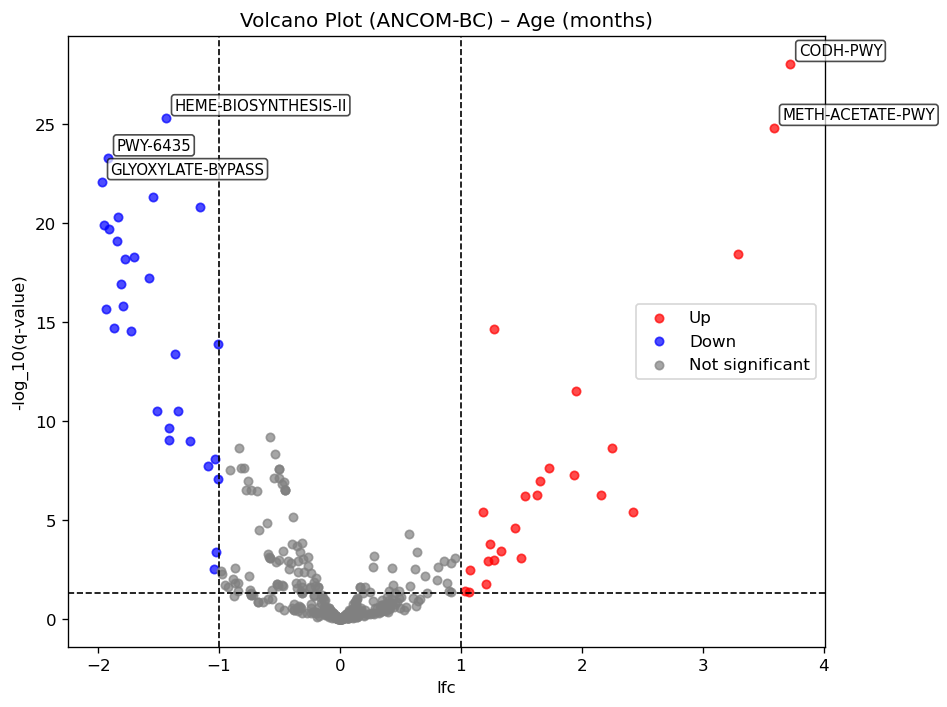

In [49]:
# Age
variable = "age"               
effect = "age_groupm10"        
label = "Age (months)"         

df_ancom_age = load_ancombc_results(pathways_data_dir, variable, effect)
print(df_ancom_age.sort_values('lfc'))
volcano_plot_ancombc(df_ancom_age, label)

The volcano plot comparing predicted pathway abundances between 10 and 4 months highlights CODH-PWY as the most strongly enriched pathway at 10 months. CODH-PWY corresponds to the Reductive Acetyl-CoA pathway (Wood–Ljungdahl pathway), a key anaerobic carbon fixation pathway involved in the conversion of H₂ and CO₂ into acetate. 
The enrichment of this pathway with increasing age is biologically plausible and consistent with known age-related shifts in gut microbiome composition. Several studies have reported an increase in the abundance of Blautia with age. Importantly, our taxonomy-based analyses support this functional interpretation. In both the differential abundance and longitudinal analyses, Blautia consistently increases with age, alongside other anaerobic taxa such as Thomasclavelia and Roseburia. Species within the genus Blautia, particularly Blautia hydrogenotrophica, are known hydrogen-consuming anaerobes that utilize the Wood–Ljungdahl pathway to produce acetic acid. Together, these results suggest that the age-associated increase in Blautia contributes to a more mature, anaerobic gut ecosystem with an enhanced capacity for acetate production via the Wood–Ljungdahl pathway. [[Liu, X. et al., 2021](https://doi.org/10.1080/19490976.2021.1875796), [Lee, H. et al., 2022](https://www.frontiersin.org/journals/microbiology/articles/10.3389/fmicb.2022.865168/full), [Sagheddu, V. et al., 2017](https://pmc.ncbi.nlm.nih.gov/articles/PMC5483434/)]

A study examining microbiome development during the first 18 months of life similarly reported that age was strongly associated with functional pathways, including methanogenesis from acetate (METH-ACETATE-PWY) [Robertson, R.C. et al., 2023](https://www.nature.com/articles/s41467-023-36135-6).



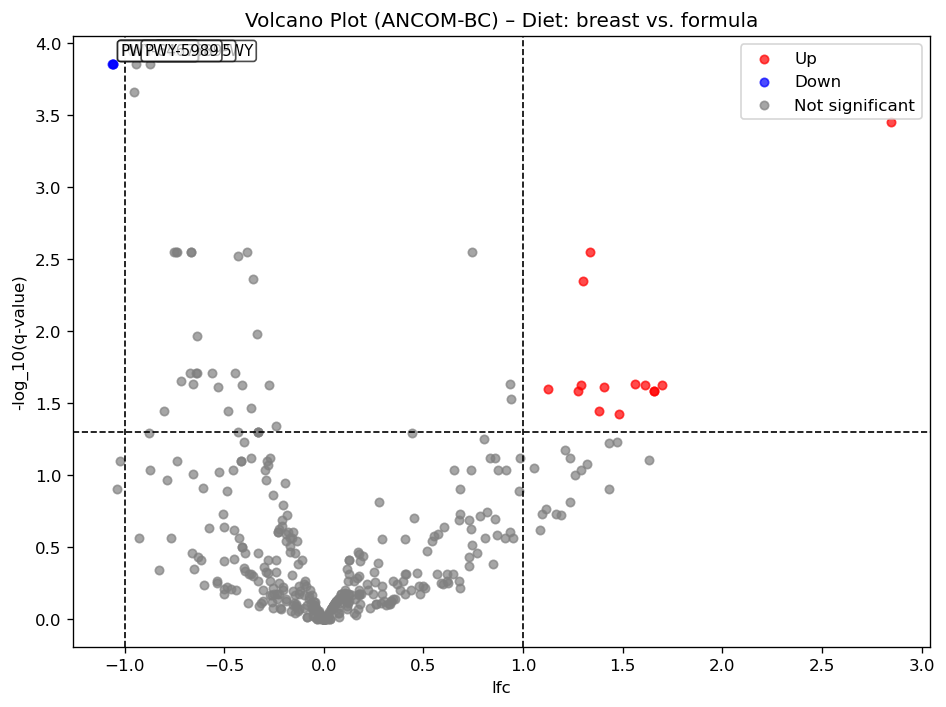

In [50]:
# Diet
variable = "diet"
effect = "diet_milkfd"
label = "Diet: breast vs. formula"

df_ancom_diet = load_ancombc_results(pathways_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_diet, label)

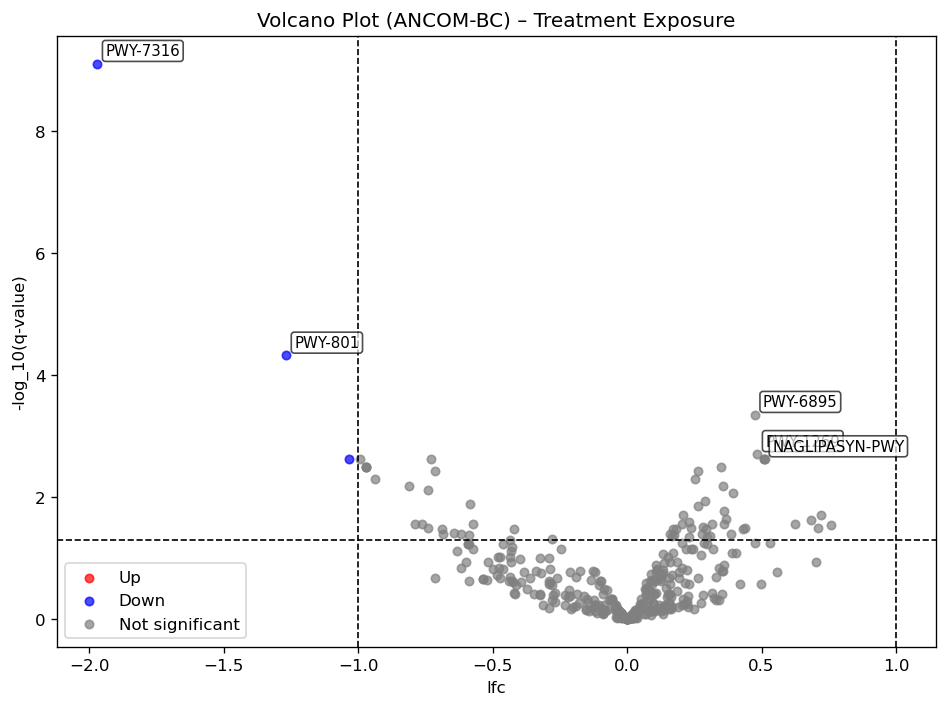

In [51]:
# Treatment exposure
variable = "treatment"
effect = "treatment_exposure_strt_True" 
label = "Treatment Exposure"
df_ancom_treatment = load_ancombc_results(pathways_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_treatment, label)

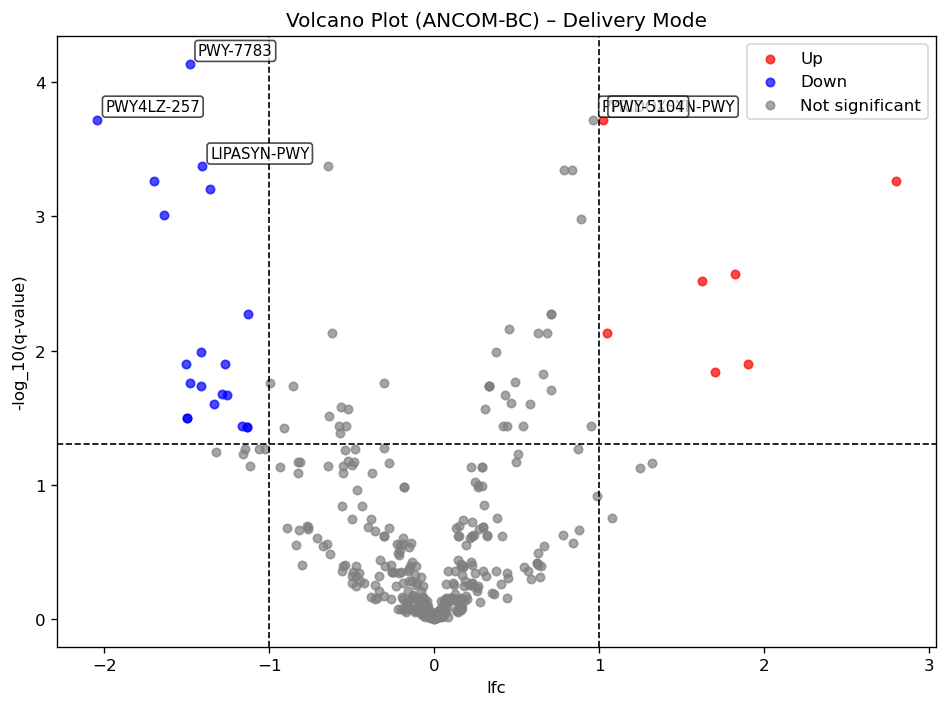

In [52]:
# Delivery mode
variable = "deliverymode"               
effect = "delivery_modevaginal"        
label = "Delivery Mode"         

df_ancom_deliverymode = load_ancombc_results(pathways_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_deliverymode, label)

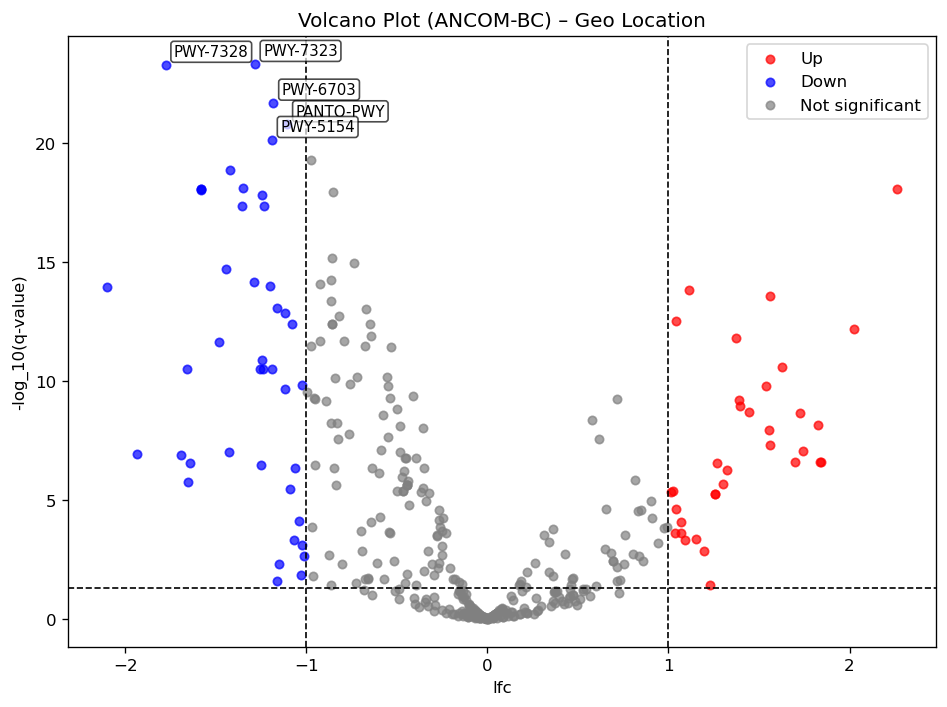

In [53]:
# Geo location
variable = "geolocation"               
effect = "geo_location_nameRussia"        
label = "Geo Location"         

df_ancom_geolocation = load_ancombc_results(pathways_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_geolocation, label)

### 4.3. Limitations of PICRUSt2 Functional Predictions

## References

Nearing, J.T., Douglas, G.M., Hayes, M.G. et al. Microbiome differential abundance methods produce different results across 38 datasets. Nat Commun 13, 342 (2022). https://doi.org/10.1038/s41467-022-28034-z

Lin, H., Peddada, S.D. Analysis of compositions of microbiomes with bias correction. Nat Commun 11, 3514 (2020). https://doi.org/10.1038/s41467-020-17041-7

Huang Lin and Shyamal Das Peddada. Analysis of compositions of microbiomes with bias correction. Nature communications, 11(1):3514, 2020. URL: https://www.nature.com/articles/s41467-020-17041-7, doi:10.1038/s41467-020-17041-7.   

Liu, X., Mao, B., Gu, J., Wu, J., Cui, S., Wang, G., … Chen, W. (2021). Blautia—a new functional genus with potential probiotic properties? Gut Microbes, 13(1). https://doi.org/10.1080/19490976.2021.1875796

Lee, H., Bae, J., Jin, S., Kang, S., & Cho, B.-K. (2022). Engineering Acetogenic Bacteria for Efficient One-Carbon Utilization. Frontiers in Microbiology, 13. https://doi.org/10.3389/fmicb.2022.865168

Sagheddu, V., Patrone, V., Miragoli, F., & Morelli, L. (2017). Abundance and Diversity of Hydrogenotrophic Microorganisms in the Infant Gut before the Weaning Period Assessed by Denaturing Gradient Gel Electrophoresis and Quantitative PCR. Frontiers in nutrition, 4, 29. https://doi.org/10.3389/fnut.2017.00029

Robertson, R.C., Edens, T.J., Carr, L. et al. The gut microbiome and early-life growth in a population with high prevalence of stunting. Nat Commun 14, 654 (2023). https://doi.org/10.1038/s41467-023-36135-6